# 05-Nicht Überwachtes Lernen

# Strategien beim nicht überwachten Lernen

Beim nicht überwachten Lernen ist das Ziel Muster, Strukturen oder Zusammenhänge in unbeschrifteten Daten erkennen. Hierzu werden verschiedene Statistische Methoden verwendet. 
Im Allgemeinen gibt es zwei grobe Hauptrichtungen:

- Dimensionsreduktion
- Clustering

## Dimensionsreduktion

Bei der Dimensionsreduktion werden Datensätzen unter Erhalt wesentlicher Informationen vereinfacht. Dies kann hilfreich sein, um Hauptunterscheidungsmerkmale zu definieren oder die Komplexität eines folgenden neuronalen Netzes zu reduzieren.

## Clustering

Beim Clustering werden Datenpunkte basierend auf Ähnlichkeiten in Gruppen zusammengefasst. Daten in einer Gruppe können dann beispielsweise einer Kategorie zugeordnet werden.

# Dimensionsreduktion

Dimensionsreduktion wird benötigt, um komplexe, hochdimensionale Daten verständlich, effizient und modellierbar zu machen.

Weniger Dimensionen bedeuten:

- einfachere Möglichkeiten 
- Fokus auf relevante Strukturen
- weniger Rechenaufwand
- kürzere Trainingszeiten bei Machine-Learning-Modellen
- geringerer Speicherverbrauch

## Principal Component Analysis

Die Hauptkomponentenanalyse (auch principal component analysis, PCA) rotiert das Koordinatensystem so, dass die Koordinaten des rotierten Systems in Richtung der Hauptachsen des Systems zeigen (Hauptachsentransformation). Zusätzlich werden die Koordinaten so verschoben, dass der Datenmittelpunkt auf dem Ursprung eines neuen Koordinatensystems zu liegen kommt. Die erste Achse des transformierten Systems in die Richtung, in der die Daten am stärksten streuen. Die zweite Achse zeigt orthogonal zur ersten Achse in Richtung der zweitgrößten Streuung, usw. (siehe auch [https://de.wikipedia.org/wiki/Hauptkomponentenanalyse](https://de.wikipedia.org/wiki/Hauptkomponentenanalyse) ).
Anders ausgedrückt zeigt die erste Achse in Richtung des Ergebnisses einer linearen Regression (genauer [Deming-Regression](https://de.wikipedia.org/wiki/Deming-Regression)) durch die Daten. 

--------------------------------------

**Mathematisch gesehen bedeitet dies:**

Ein Datensatz habe $m$ Feature und $n$ Messungen. Dann ist der i-te Datenpunkt ein Vektor  $\in \mathbb{R}^m$

Sei $\vec{X}_i \in \mathbb{R}^{m}$ der Vektor aus den Werten der bestimmten Parametern (= eine Zeile im Datensatz)

$$\vec{X}_i = \begin{pmatrix} x_{i1} \\ x_{i2} \\ ... \\ x_{im}\end{pmatrix}$$

und $\boldsymbol{X} \in \mathbb{R}^{n\times m}$ die Matrix
$$\boldsymbol{X} = \begin{pmatrix} X_1^T \\ X_2^T \\ ... \\ X_n^T\end{pmatrix} = \begin{pmatrix} x_{11} & x_{12} & ... & x_{1m} \\ x_{21} & x_{22} & ... & x_{2m} \\ ... & ...& ...& ...\\ x_{n1} & x_{n2} & ... & x_{nm}  \end{pmatrix}$$

Der Mittelwert jedes einzelnen Features ist dann $\mu_j = \bar{x}_j = \frac{1}{n}\sum_{i=1}^n x_{ij}$

und

$$\vec{\mu} = \begin{pmatrix} \mu_1 \\ \mu_2 \\ ... \\ \mu_m\end{pmatrix} $$

mit $\vec{\mu} \in \mathbb{R}^m$. 

Die zentrierte Datenmatrix ist dann

$$ \boldsymbol{X}_C = \boldsymbol{X} - \boldsymbol{1}\vec{\mu}^T$$

Und die Feature-Kovarianzmatrix ist

$$\boldsymbol{S} = \frac{1}{n-1}\boldsymbol{X}_C^T\boldsymbol{X}_C \in \mathbb{R}^{m\times m}$$

Die Stichproben-Covarianzmatrix von $\boldsymbol{X}$ ist damit

$$\boldsymbol{S} = Cov \left( \vec{X} \right) = \begin{pmatrix} \sigma_1^2 & \sigma_{12} & ... & \sigma_{1m} \\ \sigma_{21} & \sigma_2^2 & ... & \sigma_{2m} \\ ... & ... & ... & ... \\ \sigma_{m1} & \sigma_{m2} & ... & \sigma_{m}^2 \end{pmatrix}$$

wobei 

$$\sigma_{jk} = \frac{1}{n-1}\sum_{i=1}^n \left(x_{ij} - \mu_j \right) \left( x_{ik} - \mu_k  \right)$$

Im nächsten Schritt werden die Eigenwerte der Stichproben-Covarianzmatrix bestimmt. Dazu muss das Eigenwertproblem

$$ \boldsymbol{X} \vec{v}_k = \lambda_k \vec{v}_k$$

gelöst werden. Dabei sind $\lambda_k$ die Eigenwerte und $\vec{v}_k$ die Eigenvektoren der Stichproben-Covarianzmatrix.



Nach der Berechnung der Kovarianzmatrix  $\boldsymbol S \in \mathbb{R}^{m \times m}$ wird das Eigenwertproblem

$\boldsymbol S \vec v_k = \lambda_k \vec v_k$

gelöst. Dabei ist $\lambda_k$ der zugehörige Eigenwert und $\vec v_k \in \mathbb{R}^m$ der Eigenvektor.

Der Eigenwert $\lambda_k$ gibt die Varianz der Daten in Richtung des Eigenvektors $\vec v_k$ an.  

Große Eigenwerte entsprechen Richtungen, in denen die Daten stark streuen; kleine Eigenwerte stehen für Richtungen mit geringer Streuung.

Die Eigenwerte werden absteigend sortiert:


$$\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_m$$

Die erste Hauptkomponente ist somit die Richtung maximaler Varianz.

Die Eigenvektoren bilden die neuen Koordinatenachsen. Spaltenweise zusammengefasst ergeben Sie die Eigenvektormatrix

$$\boldsymbol V = \begin{pmatrix} \vec v_1 & \vec v_2 & \dots & \vec v_m \end{pmatrix}\in \mathbb{R}^{m \times m}$$

$\boldsymbol V$ ist die orthogonale Matrix der Eigenvektoren der Kovarianzmatrix und beschreibt die Rotationsmatrix des neuen Koordinatensystems.

Da die Kovarianzmatrix symmetrisch ist, sind die Eigenvektoren orthonormal. Die zentrierten Daten werden auf die neuen Achsen projiziert durch


$$\boldsymbol Z = \boldsymbol X_C \boldsymbol V$$

Dabei enthält jede Spalte von $\boldsymbol Z$ die Koordinaten der Daten in Richtung einer Hauptkomponente.

Zur Dimensionsreduktion behält man nur die ersten $k$ Eigenvektoren:

$$\boldsymbol Z_k = \boldsymbol X_C \boldsymbol V_k$$

wobei $\boldsymbol V_k \in \mathbb{R}^{m \times k}$ die Eigenvektoren zu den $k$ größten Eigenwerten enthält.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd

### Beispiel 1: Kriegsschiffe

Der Datensatz enthält 114 Einträge von Kriegsschiffen aus dem 2. Weltkrieg mit verschiedenen Parametern. 

In [2]:
data = pd.read_csv('Daten/NichtUeberwachtesLernen/kriegsschiffe.csv', sep=',')

print(data.info())
#print(data['ART'])

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ART     114 non-null    int64  
 1   DATUM   114 non-null    int64  
 2   DRAENG  114 non-null    float64
 3   LANG    114 non-null    float64
 4   BREIT   114 non-null    float64
 5   TIEF    114 non-null    float64
 6   PANZ    114 non-null    float64
 7   PS      114 non-null    float64
 8   KNOTEN  114 non-null    float64
 9   RADIUS  114 non-null    float64
 10  MANN    114 non-null    float64
 11  KLASSE  114 non-null    str    
dtypes: float64(9), int64(2), str(1)
memory usage: 10.8 KB
None


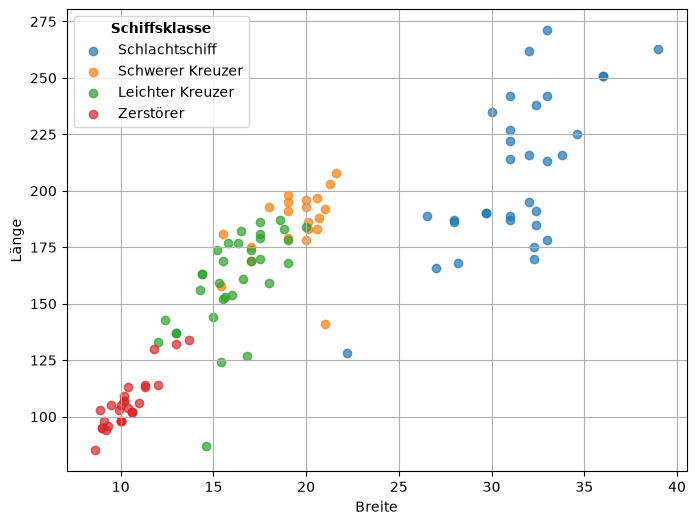

In [3]:
#1 = Schlachtschiff / Schlachtkreuzer
#3 = Schwerer Kreuzer
#4 = Leichter Kreuzer
#5 = Zerstörer

# Klassen-Mapping
class_labels = {
    1: "Schlachtschiff",
    3: "Schwerer Kreuzer",
    4: "Leichter Kreuzer",
    5: "Zerstörer"
}

plt.figure(figsize=(8,6))

for art in sorted(data["ART"].unique()):
    subset = data[data["ART"] == art]
    plt.scatter(
        subset["BREIT"],
        subset["LANG"],
        label=class_labels.get(art, str(art)),
        alpha=0.7
    )

plt.xlabel("Breite")
plt.ylabel("Länge")
plt.legend(title="Schiffsklasse", title_fontproperties={'weight': 'bold'})
plt.grid(True)

In [4]:
# PCA mit numpy

import numpy as np

features = ["DATUM","DRAENG","LANG","BREIT","TIEF","PANZ","PS","KNOTEN","RADIUS","MANN"]


X = data[features].to_numpy(dtype=float)

# Standardisierung (z-score): Xz = (X - mean) / std
mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=1)
Xz = (X - mu) / sigma

# Kovarianzmatrix (p x p)
C = np.cov(Xz, rowvar=False)

# Eigenzerlegung (C ist symmetrisch -> eigh)
eigvals, eigvecs = np.linalg.eigh(C)

# Absteigend sortieren
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Erklärte Varianzanteile
explained_ratio = eigvals / eigvals.sum()
cum_ratio = np.cumsum(explained_ratio)

print("Explained variance ratio:", explained_ratio[:5])
print("Cumulative:", cum_ratio[:5])

# Projektion auf k Komponenten
k = 2
Z = Xz @ eigvecs[:, :k]   # (n x k)

print("Scores shape:", Z.shape)


Explained variance ratio: [0.60385396 0.22634044 0.08422763 0.03589639 0.01538188]
Cumulative: [0.60385396 0.8301944  0.91442203 0.95031843 0.9657003 ]
Scores shape: (114, 2)


In [5]:
# Loadings: Korrelation Feature <-> Komponente (bei standardisierten X oft ~ eigvecs * sqrt(eigval))
loadings = eigvecs[:, :k] * np.sqrt(eigvals[:k])

loading_df = pd.DataFrame(loadings, index=features, columns=[f"PC{i+1}" for i in range(k)])
print(loading_df.sort_values("PC1", key=np.abs, ascending=False).head(10))

             PC1       PC2
BREIT   0.981728 -0.058167
DRAENG  0.947639 -0.011211
TIEF    0.945107 -0.214818
MANN    0.943035  0.139282
PANZ   -0.929105  0.101395
LANG    0.887880  0.325441
KNOTEN -0.562947  0.778759
PS      0.503305  0.756756
RADIUS  0.393416  0.308099
DATUM  -0.132741  0.896708


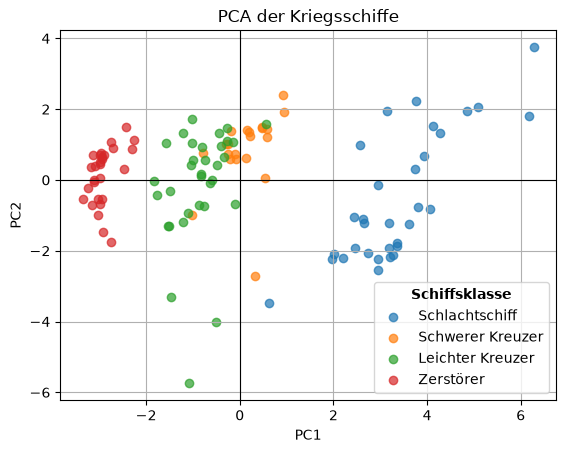

In [6]:
class_labels = {
    1: "Schlachtschiff",
    3: "Schwerer Kreuzer",
    4: "Leichter Kreuzer",
    5: "Zerstörer"
}

df_scores = data.copy()
df_scores["PC1"] = Z[:, 0]
df_scores["PC2"] = Z[:, 1]


for art in sorted(df_scores["ART"].unique()):
    subset = df_scores[df_scores["ART"] == art]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_labels.get(art, str(art)),
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")  # <- vorher hattest du zweimal xlabel
plt.title("PCA der Kriegsschiffe")
plt.legend(title="Schiffsklasse", title_fontproperties={'weight': 'bold'})
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

Jetzt mit Scikid Learn!

In [7]:
# PCA mit sklearn
 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
Xz_sk = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Z_sk = pca.fit_transform(Xz_sk)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

# Komponenten (Richtungsvektoren in Feature-Raum)
components = pca.components_  # shape: (k, p)
components_df = pd.DataFrame(components.T, index=features, columns=["PC1","PC2"])
print(components_df.sort_values("PC1", key=np.abs, ascending=False).head(10))


Explained variance ratio: [0.60385396 0.22634044]
Cumulative: [0.60385396 0.8301944 ]
             PC1       PC2
BREIT   0.399508 -0.038663
DRAENG  0.385636 -0.007452
TIEF    0.384605 -0.142788
MANN    0.383762  0.092579
PANZ   -0.378093  0.067396
LANG    0.361317  0.216317
KNOTEN -0.229087  0.517633
PS      0.204817  0.503008
RADIUS  0.160098  0.204790
DATUM  -0.054018  0.596033


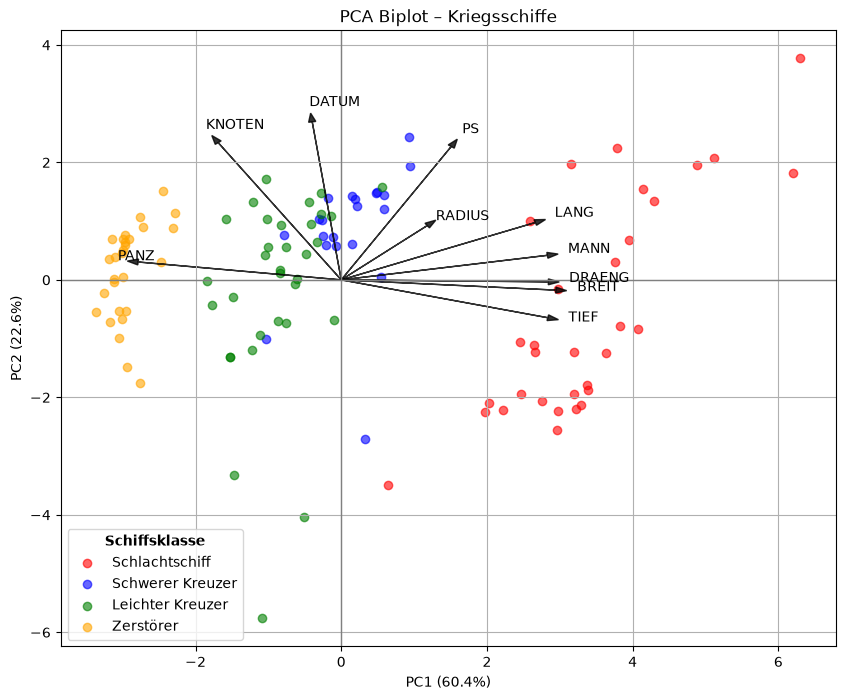

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Scores-DataFrame erstellen
df_scores = data.copy()
df_scores["PC1"] = Z_sk[:, 0]
df_scores["PC2"] = Z_sk[:, 1]

plt.figure(figsize=(10,8))

# ----- 1) Punkte (Schiffe) -----

class_labels = {
    1: "Schlachtschiff",
    3: "Schwerer Kreuzer",
    4: "Leichter Kreuzer",
    5: "Zerstörer"
}

colors = {
    1: "red",
    3: "blue",
    4: "green",
    5: "orange"
}

for art in sorted(df_scores["ART"].unique()):
    subset = df_scores[df_scores["ART"] == art]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_labels.get(art, str(art)),
        color=colors.get(art, None),
        alpha=0.6
    )

# ----- 2) Variablen-Pfeile (Loadings) -----

# Skalierungsfaktor für bessere Sichtbarkeit
scale = 3

for i, feature in enumerate(features):
    plt.arrow(
        0, 0,
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        color="black",
        alpha=0.8,
        head_width=0.1
    )
    
    plt.text(
        loadings[i, 0] * scale * 1.1,
        loadings[i, 1] * scale * 1.1,
        feature,
        fontsize=10
    )

# ----- Layout -----

plt.xlabel(f"PC1 ({explained_ratio[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_ratio[1]*100:.1f}%)")
plt.title("PCA Biplot – Kriegsschiffe")
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
plt.legend(title="Schiffsklasse", title_fontproperties={'weight': 'bold'})
plt.grid(True)

plt.show()


### Beispiel 2: Iris Datensatz

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Daten/NichtUeberwachtesLernen/iris.csv', sep = ',')

mapping = {
    "Iris-setosa": 1,
    "Iris-versicolor": 2,
    "Iris-virginica": 3
}

data["species_number"] = data["species"].apply(lambda x: mapping.get(x))

print (data.info())



<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sepal-length    150 non-null    float64
 1   sepal-width     150 non-null    float64
 2   petal-length    150 non-null    float64
 3   petal-width     150 non-null    float64
 4   species         150 non-null    str    
 5   species_number  150 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None


In [10]:
#PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ['sepal-length','sepal-width','petal-length','petal-width']

X = data[features].to_numpy(dtype=float)

# Optional: fehlende Werte entfernen (oder imputen)
mask = np.isfinite(X).all(axis=1)
X = X[mask]
df_clean = data.loc[mask].reset_index(drop=True)

print(X.shape, df_clean.shape)

scaler = StandardScaler()
Xz_sk = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Z_sk = pca.fit_transform(Xz_sk)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

# Komponenten (Richtungsvektoren in Feature-Raum)
components = pca.components_  # shape: (k, p)
components_df = pd.DataFrame(components.T, index=features, columns=["PC1","PC2"])
print(components_df.sort_values("PC1", key=np.abs, ascending=False).head(10))

(150, 4) (150, 6)
Explained variance ratio: [0.72770452 0.23030523]
Cumulative: [0.72770452 0.95800975]
                   PC1       PC2
petal-length  0.581254  0.021095
petal-width   0.565611  0.065416
sepal-length  0.522372  0.372318
sepal-width  -0.263355  0.925556


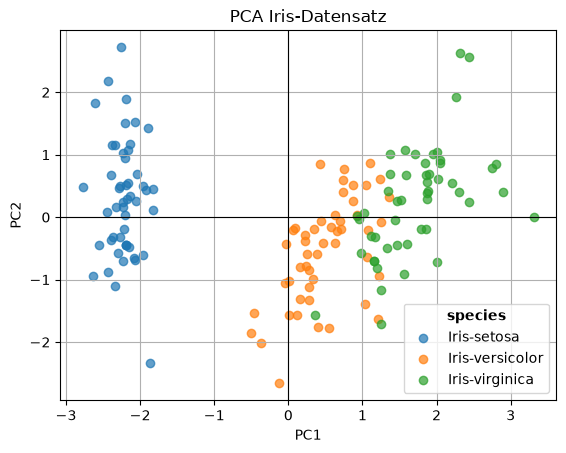

In [11]:
class_labels = {
    1: "Iris-setosa",
    3: "Iris-versicolor",
    3: "Iris-virginica"
}

df_scores = df_clean.copy()
df_scores["PC1"] = Z_sk[:, 0]
df_scores["PC2"] = Z_sk[:, 1]


for art in sorted(df_scores["species"].unique()):
    subset = df_scores[df_scores["species"] == art]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_labels.get(art, str(art)),
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")  # <- vorher hattest du zweimal xlabel
plt.title("PCA Iris-Datensatz")
plt.legend(title="species", title_fontproperties={'weight': 'bold'})
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

### Beispiel 3: Pinguin-Datensatz

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
 9   species_number     344 non-null    int64  
 10  sex_number         333 non-null    float64
dtypes: float64(5), int64(3), str(3)
memory usage: 29.7 KB
None
(342, 4) (342, 11)
Explained variance ratio: [0.68843878 0.19312919]
Cumulative: [0.68843878 0.88156797]
                        PC1       PC2
flipper_length_mm  0.576013  0.002282
body_mass_g        0.548350  0.084363

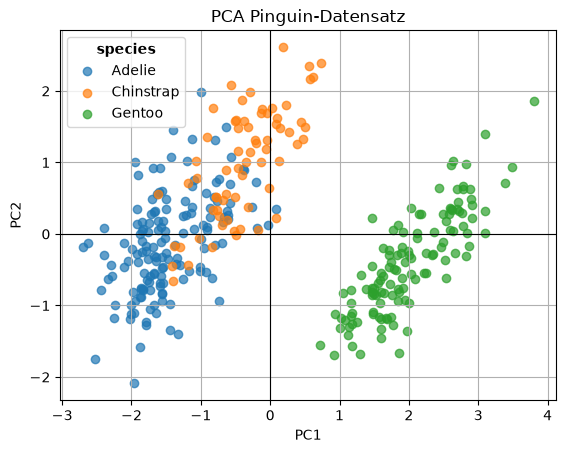

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv('Daten/NichtUeberwachtesLernen/penguins.csv', sep = ',')

mapping = {
    "Adelie": 1,
    "Gentoo": 2,
    "Chinstrap": 3
}
mapping2 = {
    "male": 1,
    "female": 2
}

data["species_number"] = data["species"].apply(lambda x: mapping.get(x))
data['sex_number'] = data['sex'].apply(lambda x: mapping2.get(x))


print (data.info())

#PCA
features = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']#,'sex_number','year']   

X = data[features].to_numpy(dtype=float)

# Optional: fehlende Werte entfernen (oder imputen)
mask = np.isfinite(X).all(axis=1)
X = X[mask]
df_clean = data.loc[mask].reset_index(drop=True)

print(X.shape, df_clean.shape)

scaler = StandardScaler()
Xz_sk = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Z_sk = pca.fit_transform(Xz_sk)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

# Komponenten (Richtungsvektoren in Feature-Raum)
components = pca.components_  # shape: (k, p)
components_df = pd.DataFrame(components.T, index=features, columns=["PC1","PC2"])
print(components_df.sort_values("PC1", key=np.abs, ascending=False).head(10))

class_labels = {
    1: "Adelie",
    2: "Gentoo",
    3: "Chinstrap"
}

df_scores = df_clean.copy()
df_scores["PC1"] = Z_sk[:, 0]
df_scores["PC2"] = Z_sk[:, 1]


for art in sorted(df_scores["species"].unique()):
    subset = df_scores[df_scores["species"] == art]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_labels.get(art, str(art)),
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")  # <- vorher hattest du zweimal xlabel
plt.title("PCA Pinguin-Datensatz")
plt.legend(title="species", title_fontproperties={'weight': 'bold'})
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)



## t-SNE

Bei t-SNE handelt es sich um einen Algorithmus, der auf die Visualisierung abzielt. 
Mit t-SNE wird eine neue Repräsentation der Daten berechnet, daher lässt sie sich nur auf die Trainingsdaten, nicht auf die Testdaten anwenden.

t-SNE (t-Distributed Stochastic Neighbor Embedding) ist ein Verfahren zur Dimensionsreduktion. Es wird häufig verwendet, um hochdimensionale Daten (z. B. mit vielen Features) in 2D oder 3D zu visualisieren.

t-SNE betrachtet, wie nah Datenpunkte im ursprünglichen hochdimensionalen Raum zueinander liegen.
Daraus werden Wahrscheinlichkeiten für Nachbarschaften berechnet, wobei ähnliche Punkte zu einer hohen Wahrscheinlichkeit führen.
Danach wird eine meist 2D Darstellung ermittelt, in der diese Nachbarschaften möglichst ähnlich erhalten bleiben. Mit Hilfe einer [t-Verteilung](https://de.wikipedia.org/wiki/Studentsche_t-Verteilung) werden dann weit entfernte Punkte zu stark zusammengezogen werden.

# Clustering

## kMeans

k-Means ist ein Clustering-Algorithmus, der Datenpunkte in k Gruppen (Cluster) einteilt, sodass Punkte innerhalb eines Clusters möglichst ähnlich sind.
Dazu muss zu Beginn die $k$ der zu findenden Cluster festgelegt werden.

Der Algorithmus startet mit k zufälligen Zentren (Centroids).
Jeder Datenpunkt wird dem nächstgelegenen Zentrum zugeordnet.
Die Zentren werden anschließend als Mittelwert aller Punkte im Cluster neu berechnet.

Dies wird solange wiederholt, bis sich die Zentren kaum noch ändern.

Die Daten werden also in k Cluster mit jeweils einem Mittelpunkt aufgeteilt, wobei die Abstände der Punkte zu ihren Zentren minimiert werden.

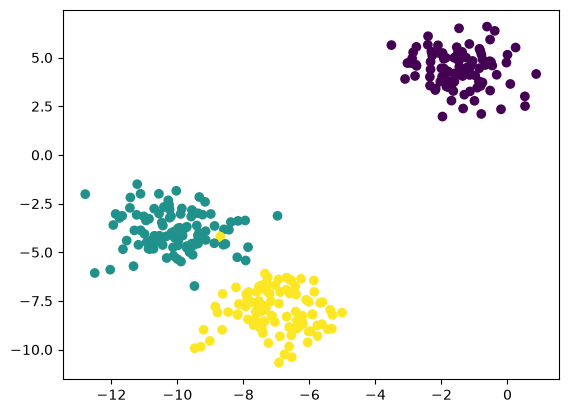

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.cm as cm
import matplotlib.lines as mlines
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

iris = load_iris()

X,y = make_blobs(n_samples=300, centers=3, random_state=1)

plt.scatter(X[:,0], X[:,1], c = y)

### KMeans zu Fuss programmieren

In [14]:
import numpy as np

def kmeans_numpy(
    X: np.ndarray,
    k: int,
    max_iter: int = 300,
    tol: float = 1e-4,
    random_state: int | None = None,
):
    """
    Einfaches K-Means (Lloyd's Algorithm) nur mit NumPy.

    Returns:
      centroids: (k, n_features)
      labels:    (n_samples,)
      inertia:   Sum of squared distances to closest centroid
      n_iter:    Anzahl Iterationen
    """
    X = np.asarray(X, dtype=float)
    n_samples, n_features = X.shape

    rng = np.random.default_rng(random_state)

    # 1) Initialisierung: wähle k zufällige Punkte als Start-Zentren
    init_idx = rng.choice(n_samples, size=k, replace=False)
    centroids = X[init_idx].copy()

    labels = np.full(n_samples, -1, dtype=int)

    for it in range(1, max_iter + 1):
        # 2) Assignment-Step: jedem Punkt nächstes Zentrum zuordnen
        # Distanz^2: ||x - c||^2 = sum((X - C)^2) über Features
        # Broadcasting: (n,1,f) - (1,k,f) -> (n,k,f) -> sum -> (n,k)
        dists_sq = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        new_labels = np.argmin(dists_sq, axis=1)

        # Falls sich Labels nicht ändern: fertig
        if np.array_equal(new_labels, labels):
            labels = new_labels
            break
        labels = new_labels

        # 3) Update-Step: Zentren = Mittelwert der zugeordneten Punkte
        new_centroids = centroids.copy()
        for j in range(k):
            mask = labels == j
            if np.any(mask):
                new_centroids[j] = X[mask].mean(axis=0)
            else:
                # Leerer Cluster: re-init auf einen zufälligen Punkt
                new_centroids[j] = X[rng.integers(0, n_samples)]

        # Konvergenz über Zentren-Bewegung
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift <= tol:
            break

    # Inertia (wie bei sklearn): Summe der quadrierten Abstände zum nächsten Zentrum
    final_dists_sq = ((X - centroids[labels]) ** 2).sum(axis=1)
    inertia = final_dists_sq.sum()

    return centroids, labels, inertia, it


Text(0.5, 1.0, 'inertia=573.94, iters=5')

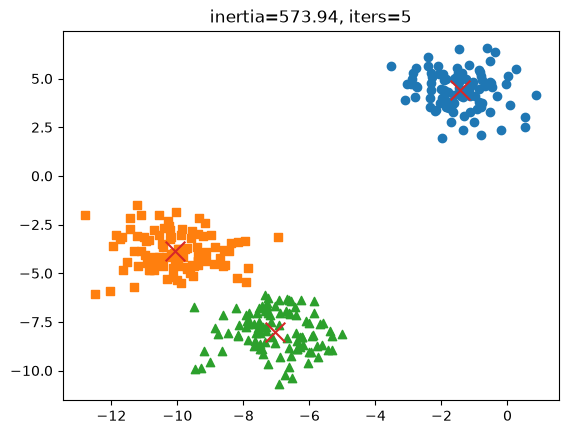

In [15]:
X, y_true = make_blobs(n_samples=300, centers=3, random_state=1)

centroids, labels, inertia, n_iter = kmeans_numpy(X, k=3, random_state=42)

markers = ['o', 's', '^', 'x', 'D']  # verschiedene Marker

for i in np.unique(labels):
    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        marker=markers[i],
        label=f"Cluster {i}"
    )
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=200)
#Inertia: Summe der quadrierten Abstände aller Punkte zu ihrem jeweiligen Cluster-Zentrum
#n_iter: Das ist die Anzahl der Iterationen, die K-Means gebraucht hat, bis es konvergiert ist.
plt.title(f"inertia={inertia:.2f}, iters={n_iter}") 

### KMeans mit sklearn

Nutzt verbessertes KMeans: Statt alle Zentren zufällig zu wählen, werden sie strategisch verteilt

In [16]:
X, y = make_blobs(n_samples=300, centers=3, random_state=1)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
feature_names = ['Merkmal 1', 'Merkmal 2']
klassennamen = ['Blob 1', 'Blob 2', 'Blob 3']
pred = kmeans.labels_
print(pred)

[2 0 2 1 1 1 2 1 1 0 0 0 2 2 0 1 2 2 1 2 2 2 1 1 1 2 2 1 2 2 1 0 0 2 0 2 0
 1 0 1 1 0 1 1 2 2 1 0 2 2 0 2 2 2 1 2 1 0 1 2 2 0 0 1 1 0 0 1 0 2 1 1 1 2
 1 2 0 1 1 2 2 2 1 2 1 0 2 2 1 2 0 1 2 0 2 0 2 2 0 0 2 0 1 0 0 1 1 2 0 2 0
 2 0 1 2 1 0 2 2 1 2 1 0 2 0 1 1 2 0 2 0 2 1 0 0 2 0 2 2 2 0 1 1 0 2 0 1 2
 0 1 0 2 0 2 1 0 0 2 0 2 2 1 1 0 1 2 0 1 1 2 1 2 2 1 1 1 0 2 0 0 1 2 1 2 1
 1 1 0 2 0 2 1 1 1 1 2 1 2 1 1 0 0 2 0 0 1 0 2 0 2 1 0 0 1 0 1 0 2 1 1 2 0
 2 1 0 1 2 1 1 0 1 2 0 0 1 0 2 0 0 1 0 1 0 2 1 0 1 1 1 2 1 0 2 0 1 0 2 0 2
 1 2 0 1 2 0 1 1 2 2 0 0 1 0 0 1 0 0 0 1 0 1 0 2 0 0 2 0 2 0 0 2 2 1 2 2 1
 2 0 0 0]


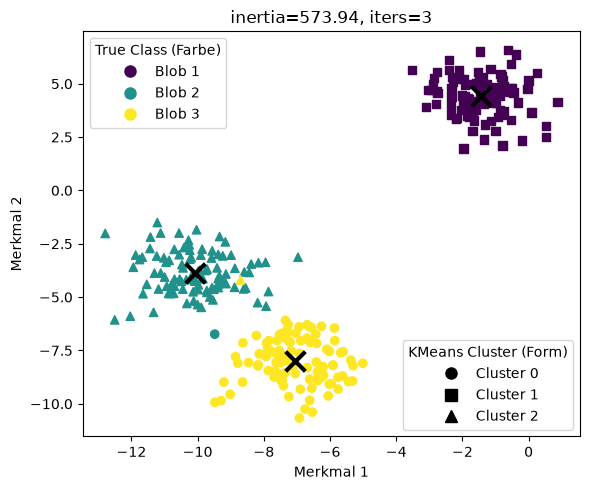

In [17]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

cmap = plt.colormaps.get_cmap('viridis').resampled(3)
norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

plt.figure(figsize=(6,5))

# --- Scatter ---
for cluster in np.unique(labels):
    mask = labels == cluster
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        c=y[mask],
        cmap=cmap, norm=norm,
        marker=markers[cluster]
    )

# --- Zentren ---
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='x',
    s=200,
    linewidths=3,
    color='black'
)

# =========================
# 1️⃣ Farblegende (echte Klassen)
# =========================
color_handles = []
for i, class_name in enumerate(klassennamen):
    color = cmap(i)
    handle = mlines.Line2D(
        [], [], 
        color=color, 
        marker='o', 
        linestyle='None',
        markersize=8,
        label=class_name
    )
    color_handles.append(handle)

legend1 = plt.legend(
    handles=color_handles,
    title="True Class (Farbe)",
    loc="upper left"
)
plt.gca().add_artist(legend1)

# =========================
# 2️⃣ Markerlegende (KMeans)
# =========================
marker_handles = []
for i in np.unique(labels):
    handle = mlines.Line2D(
        [], [],
        color='black',
        marker=markers[i],
        linestyle='None',
        markersize=8,
        label=f"Cluster {i}"
    )
    marker_handles.append(handle)

plt.legend(
    handles=marker_handles,
    title="KMeans Cluster (Form)",
    loc="lower right"
)

plt.title(f"inertia={kmeans.inertia_:.2f}, iters={kmeans.n_iter_}")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.tight_layout()
plt.show()


### Clusteranalyse mit Iris Dataset

Text(0.5, 1.0, 'Iris-Daten')

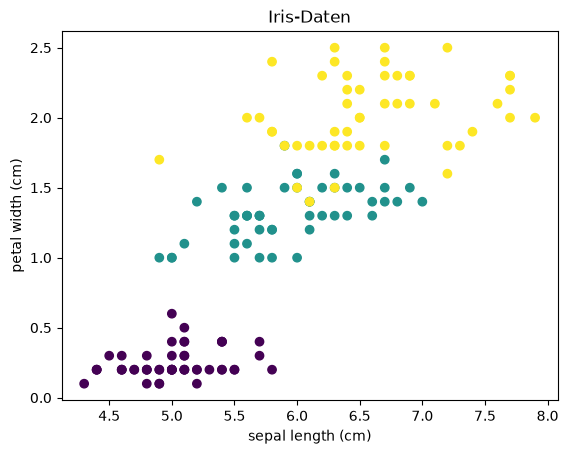

In [18]:
from sklearn.cluster import KMeans

X, y, feature_names = iris.data, iris.target, iris.feature_names

plt.scatter(X[:,0], X[:,3], c = y)
plt.xlabel(str(feature_names[0]))
plt.ylabel(str(feature_names[3]))
plt.title('Iris-Daten')

In [19]:
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

print(kmeans.predict(X))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
Centroids: [[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


Text(0, 0.5, 'petal width (cm)')

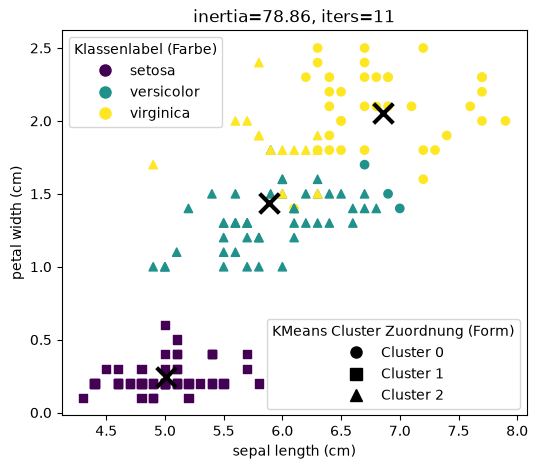

In [20]:
labels = kmeans.labels_
print('Labels:', labels)
centroids = kmeans.cluster_centers_
print('Centroids:', centroids)

import matplotlib.lines as mlines

cmap = plt.colormaps.get_cmap('viridis').resampled(3)
norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

plt.figure(figsize=(6,5))

# --- Scatter ---
for cluster in np.unique(labels):
    mask = labels == cluster
    plt.scatter(
        X[mask, 0],
        X[mask, 3],
        c=y[mask],
        cmap=cmap, norm=norm,
        marker=markers[cluster]
    )

# --- Zentren ---
plt.scatter(
    centroids[:, 0],
    centroids[:, 3],
    marker='x',
    s=200,
    linewidths=3,
    color='black'
)

# =========================
# 1️⃣ Farblegende (echte Klassen)
# =========================
color_handles = []
for i, class_name in enumerate(iris.target_names):
    color = cmap(i)
    handle = mlines.Line2D(
        [], [], 
        color=color, 
        marker='o', 
        linestyle='None',
        markersize=8,
        label=class_name
    )
    color_handles.append(handle)

legend1 = plt.legend(
    handles=color_handles,
    title="Klassenlabel (Farbe)",
    loc="upper left"
)
plt.gca().add_artist(legend1)

# =========================
# 2️⃣ Markerlegende (KMeans)
# =========================
marker_handles = []
for i in np.unique(labels):
    handle = mlines.Line2D(
        [], [],
        color='black',
        marker=markers[i],
        linestyle='None',
        markersize=8,
        label=f"Cluster {i}"
    )
    marker_handles.append(handle)

plt.legend(
    handles=marker_handles,
    title="KMeans Cluster Zuordnung (Form)",
    loc="lower right"
)

plt.title(f"inertia={kmeans.inertia_:.2f}, iters={kmeans.n_iter_}")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[3])


## DBSCAN

kmeans ist ein gutes Clustering-Tool, aber k-Means kann nur zentrierte Cluster finden, weil der Algorithmus jedes Cluster ausschließlich durch einen Mittelpunkt beschreibt und Punkte anhand ihres Abstands zu diesem Mittelpunkt zuordnet.

Eine Alternative ist DBSCAN (density-based spacial clustering of applications with noise). 
DBSCAN ist ein Clustering-Algorithmus, der Gruppen von Datenpunkten anhand ihrer Dichte findet.
Der Clusterparameter ist die Mindestanzahl an Punkten pmin, die ein Cluster haben muss. 

Für jeden Punkt wird geprüft, wie viele andere Punkte sich in einem Radius befinden. Hat ein Punkt mindestens pmin Nachbarn, wird er als Kernpunkt betrachtet. Von Kernpunkten aus werden benachbarte Punkte zu einem Cluster verbunden. Punkte, die zu keinem dichten Bereich gehören, werden als Rauschen (Noise) markiert.

Damit entstehen Cluster dort, wo viele Punkte dicht beieinander liegen. DBSCAN kann auch Cluster mit beliebiger Form finden und benötigt keine vorher festgelegte Clusterzahl.

DBSCAN funktioniert schlecht wenn Cluster unterschiedliche Punktdichten haben. Auch ist die Wahl von eps oft nicht trivial. Für sehr große Datenmengen kann die Nachbarschaftssuche relativ rechenintensiv werden.

Text(0, 0.5, 'Merkmal 2')

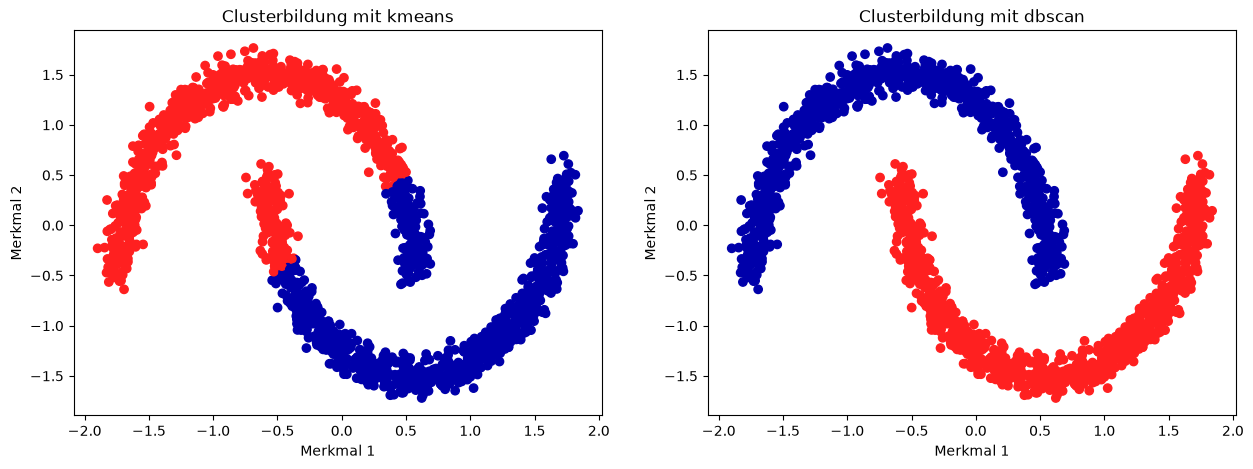

In [21]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import mglearn

X,y = make_moons(n_samples = 2000, noise = 0.05, random_state = 0)
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
k_clusters = kmeans.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_clusters = dbscan.fit_predict(X)

fig, [ax1,ax2] = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(15)

ax1.scatter(X_scaled[:,0], X_scaled[:,1], c = k_clusters, cmap = mglearn.cm2)
ax1.set_title('Clusterbildung mit kmeans')
ax1.set_xlabel('Merkmal 1')
ax1.set_ylabel('Merkmal 2')
ax2.scatter(X_scaled[:,0], X_scaled[:,1], c = db_clusters, cmap = mglearn.cm2)
ax2.set_title('Clusterbildung mit dbscan')
ax2.set_xlabel('Merkmal 1')
ax2.set_ylabel('Merkmal 2')


# Beispiel: Zahlen erkennen 

## Schritt 1: Zahlen einlesen

In [42]:
from glob import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 

liste_daten = glob('Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert*.png')
for i in liste_daten:
    print(i)

Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert09.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert08.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert06.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert12.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert13.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert07.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert11.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert05.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert04.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert10.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert14.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert01.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert03.png
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert02.png


In [44]:
def imshow(name, img, size=8):
    import matplotlib.pyplot as plt
    from IPython.display import display
    import cv2

    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    aspect = w / h
    plt.figure(figsize=(size * aspect, size))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(name)
    plt.axis('off')

# contours are not sorted, so sort them to assign the correct labels later
def sort_contours_grid(contours, row_height=50):
    # Extract bounding boxes
    bounding_boxes = [cv2.boundingRect(c) for c in contours]

    # Combine contours with their boxes
    contours_with_boxes = list(zip(contours, bounding_boxes))

    # First sort top-to-bottom by y
    contours_with_boxes.sort(key=lambda b: b[1][1])  # b[1][1] = y

    # Group contours into rows based on y
    rows = []
    current_row = []
    last_y = -row_height

    for c, (x, y, w, h) in contours_with_boxes:
        if y - last_y > row_height:
            if current_row:
                rows.append(current_row)
            current_row = [(c, (x, y, w, h))]
            last_y = y
        else:
            current_row.append((c, (x, y, w, h)))
    if current_row:
        rows.append(current_row)

    # Now sort each row left to right
    sorted_contours = []
    for row in rows:
        row.sort(key=lambda b: b[1][0])  # sort by x
        sorted_contours.extend([c for c, _ in row])

    return sorted_contours

contour_height = 22

x_data_list = []
response_list = []

for im in liste_daten:
    print(im)
    image = cv2.imread(im)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    thresh = cv2.adaptiveThreshold(blur,255,1,1,11,2)

    # find digits in image and create contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    no_digits = 0

    #Sortieren der Konturen von oben nach unten und links nach rechts
    contours = sort_contours_grid(contours)

    for cnt in contours:
        # print(cv2.contourArea(cnt))
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                roi = thresh[y:y+h, x:x+w]
                roismall = cv2.resize(roi, (28, 28))
                x_data_list.append(roismall)
                no_digits +=1

    # now generate labels
    print(no_digits, no_digits/10)
    # create list of labels
    list_of_digits = [0,1,2,3,4,5,6,7,8,9]
    
    for element in range(int(no_digits/10)):
        response_list.append(list_of_digits)

#finalize the data
x_data = np.array(x_data_list)
response = np.array(response_list)
y_data = response.flatten()

print(x_data.shape)
print(y_data.shape)

Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert09.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert08.png
210 21.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert06.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert12.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert13.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert07.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert11.png
210 21.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert05.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert04.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert10.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert14.png
210 21.0
Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Handschrift_sortiert01.png
220 22.0
Daten/NichtUeberwachtesLernen/Zahlen/Zah

In [45]:
# Hauptkomponentenanalyse

# Daten auf Form bringen, die pca erwartet
X = x_data.reshape(len(x_data), -1).astype(np.float32)

pca = PCA(n_components=2)
pca.fit(X)
X_2d = pca.transform(X)
print(X_2d)
print(y_data)

[[1232.8066   797.6687 ]
 [-867.35834 -525.1486 ]
 [-131.22992  695.1494 ]
 ...
 [-849.3553   182.54883]
 [ 400.1693  -195.0055 ]
 [ 182.68433 -634.7799 ]]
[0 1 2 ... 7 8 9]


(3040, 2)
(3040,)


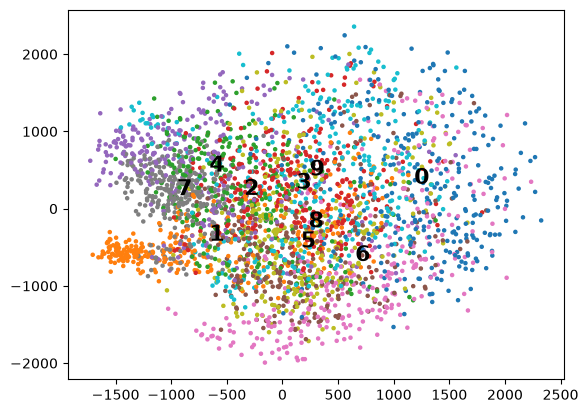

In [46]:
print(X_2d.shape)
print(y_data.shape)

plt.scatter(X_2d[:,0], X_2d[:,1], c=y_data, cmap="tab10", s=5)

for digit in range(10):
    idx = y_data == digit
    x_mean = X_2d[idx,0].mean()
    y_mean = X_2d[idx,1].mean()
    plt.text(x_mean, y_mean, str(digit), fontsize=16, weight='bold')

plt.show()

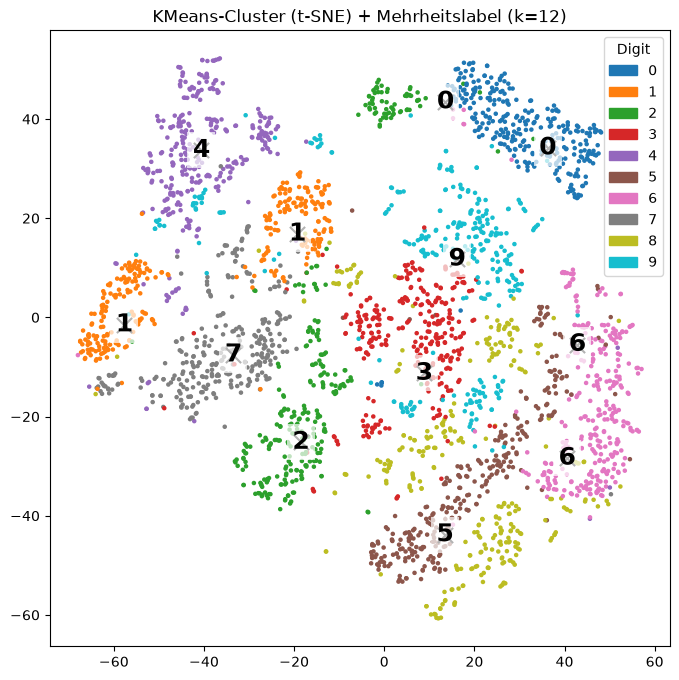

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# X: (n_samples, n_features) z.B. (n,784)
# y_data: (n,) mit Labels 0..9

# 1) t-SNE auf 2D
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(X)   # (n,2)

# 2) KMeans auf den 2D t-SNE Punkten
k = 12 
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
cluster_id = kmeans.fit_predict(digits_tsne)
centers = kmeans.cluster_centers_

# 3) Cluster -> Ziffer (Mehrheitsvotum)
cluster_to_digit = {}
for c in range(k):
    labels = y_data[cluster_id == c]
    cluster_to_digit[c] = "?" if len(labels) == 0 else int(np.bincount(labels).argmax())

# 4) Plot
plt.figure(figsize=(8, 8))

# Punkte: Farbe = echtes Label
plt.scatter(digits_tsne[:,0], digits_tsne[:,1], c=y_data, cmap="tab10", s=5)

# Clusterzentren
plt.scatter(centers[:,0], centers[:,1], c="black", s=120, marker="x")

# Text im Zentrum
for c in range(k):
    plt.text(
        centers[c,0], centers[c,1], str(cluster_to_digit[c]),
        fontsize=18, weight="bold",
        ha="center", va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

# Legende (0..9 Farben)
cmap = plt.colormaps["tab10"]
legend_handles = [mpatches.Patch(color=cmap(i), label=str(i)) for i in range(10)]
plt.legend(handles=legend_handles, title="Digit")

plt.title(f"KMeans-Cluster (t-SNE) + Mehrheitslabel (k={k})")
plt.show()

# Autoencoder

Ein Autoencoder ist ein neuronales Netzwerk, das Daten komprimiert (Encoder) und wieder rekonstruiert (Decoder). Da es nicht perfekt kopieren darf, lernt es automatisch wichtige Merkmale der Daten zu erkennen.

Ein Autoencoder besteht aus zwei Komponenten, eine Encoder und einem Decoder

$$x \longrightarrow f(x) \longrightarrow h \longrightarrow g(h) \longrightarrow r$$

Autoenoder sind feed-forward Netze.





## undercomplete Autoencoders

Bei den undercomplete Autoencodern ist der Encoder

$$x \longrightarrow f(x) \longrightarrow h$$

und der Decoder

$$h \longrightarrow g(h) \longrightarrow r$$

Dabei ist 

$$dim(x) = dim(r)$$

und 

$$dim(h) < dim(x)$$

Der Autoencoder lernt dadurch, die Daten durch die wichtigsten Eigenschaften zu repräsentieren.
Haben Encoder und Decoder lineare Aktivierungsfunktionen, ist das Ergebnis das gleiche, wie bei einer PCA.

Aber die Aktivierungsfunktionen können natürlich auch nichtlinear sein.

Die Lossfunktion, die minimiert wird ist

$$ L( \mathbf{x}, g(f(\mathbf{x}))) = \sum_i \left( x_i - g(f(x_i)) \right)^2 $$

In [48]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print (x_train.shape)
print (x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [49]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [50]:
import numpy as np

input_dim = 784
latent_dim = 64

# Wähle zum Start zufällige kleine Gewichte
# b ist Bias
W1 = np.random.randn(input_dim, latent_dim) * 0.01
b1 = np.zeros((1, latent_dim))

W2 = np.random.randn(latent_dim, input_dim) * 0.01
b2 = np.zeros((1, input_dim))

In [51]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

In [52]:
def forward(x):
    z1 = x @ W1 + b1
    h = relu(z1)

    z2 = h @ W2 + b2
    r = sigmoid(z2)

    cache = (x, z1, h, z2, r)
    return r, cache

In [53]:
#Loss-Funktion
def mse_loss(x, r):
    return np.mean((x - r) ** 2)

In [54]:
def backward(cache):
    global W1, b1, W2, b2

    x, z1, h, z2, r = cache
    # m = Anzahl der Trainingsbeispiele im Batch
    m = x.shape[0]

    # dL/dr
    dr = (r - x) * 2 / m

    # Decoder
    dz2 = dr * sigmoid_deriv(z2)
    dW2 = h.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Encoder
    dh = dz2 @ W2.T
    dz1 = dh * relu_deriv(z1)
    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [55]:
lr = 0.001
epochs = 10
batch_size = 256

for epoch in range(epochs):
    perm = np.random.permutation(x_train.shape[0])
    x_train_shuffled = x_train[perm]

    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train_shuffled[i:i+batch_size]

        # Forward
        r, cache = forward(x_batch)

        # Loss
        loss = mse_loss(x_batch, r)

        # Backward
        dW1, db1, dW2, db2 = backward(cache)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.0899
Epoch 2, Loss: 0.0898
Epoch 3, Loss: 0.0734
Epoch 4, Loss: 0.0712
Epoch 5, Loss: 0.0654
Epoch 6, Loss: 0.0570
Epoch 7, Loss: 0.0535
Epoch 8, Loss: 0.0512
Epoch 9, Loss: 0.0493
Epoch 10, Loss: 0.0526


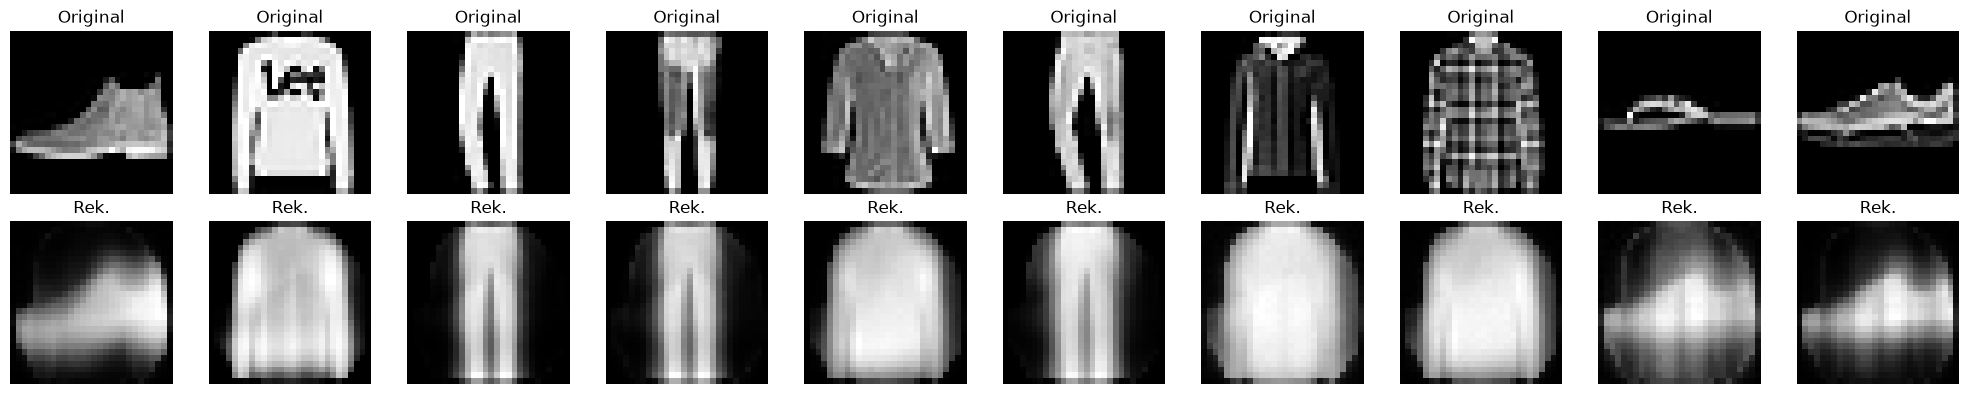

In [56]:
import matplotlib.pyplot as plt

# einige Testbilder auswählen
n = 10
x_sample = x_test[:n]

# Rekonstruktionen berechnen
reconstructions, _ = forward(x_sample)

# Plot
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_sample[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Rekonstruktion
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    plt.title("Rek.")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 1 
Verwenden Sie lineare Aktivierungsfunktionen und vergleichen Sie das Ergebnis mit dem einer PCA

### Aufgabe 2 
Variieren Sie die Dimension von h und vergleichen Sie die Ergebnisse

In [57]:
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers, losses


(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print (x_train.shape)
print (x_test.shape)


class Autoencoder(Model):
  def __init__(self, latent_dim, shape):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.shape = shape

    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'),
    ])

    self.decoder = tf.keras.Sequential([
      layers.Dense(int(np.prod(shape)), activation='sigmoid'),
      layers.Reshape(shape)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded


shape = x_test.shape[1:]
latent_dim = 64
autoencoder = Autoencoder(latent_dim, shape)

autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))

(60000, 28, 28)
(10000, 28, 28)
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - loss: 0.0238 - val_loss: 0.0132
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - loss: 0.0116 - val_loss: 0.0106
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - loss: 0.0101 - val_loss: 0.0098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - loss: 0.0095 - val_loss: 0.0094
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - loss: 0.0092 - val_loss: 0.0092
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - loss: 0.0091 - val_loss: 0.0091
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - loss: 0.0090 - val_loss: 0.0090
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step - loss: 0.0089 - val_loss: 0.0091
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - loss: 0.0089 - val_loss: 0.0090
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - loss: 0.0088 - val_loss: 0.0089


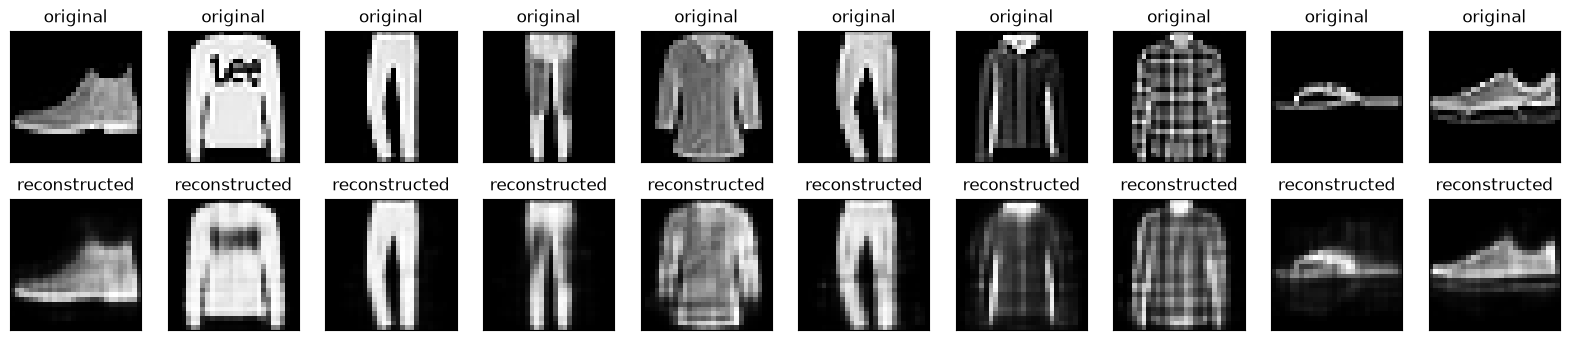

In [58]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i])
  plt.title("original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title("reconstructed")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

### Aufgabe 3
Warum liefert die Variante mit Keras bessere Ergebnisse?

### Aufgabe 4

Schreiben Sie einen Autoencoder der die Ziffern von 0-9 rekonstruieren kann!

In [61]:
#|include: false

# Daten einlesen

import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import re
import cv2

# Funktion zur numerischen Sortierung der Dateien
def extract_number(filename):
    return int(re.search(r"_sortiert(\d+)", filename).group(1))

# Alle Files einleden, die mit Zahlen_Handschrift_sortiert beginnen und direkt darauf folgend eine Zahl im Namen haben.
liste_daten = glob('Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert*[0-9].png')

# Liste numerisch sortieren und sortierte Liste ausgeben
liste_daten = sorted(liste_daten, key=extract_number)[0:14]
for el in liste_daten:
    print(el)

#| code-fold: true
#| code-summary: "Code anzeigen"


def imshow(name, img, size=8):
    import matplotlib.pyplot as plt
    from IPython.display import display
    import cv2

    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    aspect = w / h
    plt.figure(figsize=(size * aspect, size))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(name)
    plt.axis('off')
    #plt.show()

# contours are not sorted, so sort them to assign the correct labels later
def sort_contours_grid(contours, row_height=50):
    # Extract bounding boxes
    bounding_boxes = [cv2.boundingRect(c) for c in contours]

    # Combine contours with their boxes
    contours_with_boxes = list(zip(contours, bounding_boxes))

    # First sort top-to-bottom by y
    contours_with_boxes.sort(key=lambda b: b[1][1])  # b[1][1] = y

    # Group contours into rows based on y
    rows = []
    current_row = []
    last_y = -row_height

    for c, (x, y, w, h) in contours_with_boxes:
        if y - last_y > row_height:
            if current_row:
                rows.append(current_row)
            current_row = [(c, (x, y, w, h))]
            last_y = y
        else:
            current_row.append((c, (x, y, w, h)))
    if current_row:
        rows.append(current_row)

    # Now sort each row left to right
    sorted_contours = []
    for row in rows:
        row.sort(key=lambda b: b[1][0])  # sort by x
        sorted_contours.extend([c for c, _ in row])

    return sorted_contours

#| code-fold: true
#| code-summary: "Code anzeigen"

contour_height = 23

x_data_list = []
response_list = []

## Alle Bilder auswerten
for im in liste_daten[:-2]:

    print(im)
    image = cv2.imread(im)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    thresh = cv2.adaptiveThreshold(blur,255,1,1,11,2)

    # find digits in image and create contours
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    no_digits = 0
    #plt.figure(figsize = (10,15))
    #plt.imshow(image, cmap='gray')
    #plt.title(im)

    # jetzt rotes Viereck um jede Zahl zeichnen
    for cnt in contours:
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                no_digits +=1
    #            plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2))

    #Sortieren der Konturen von oben nach unten und links nach rechts
    contours = sort_contours_grid(contours)

    for cnt in contours:
        # print(cv2.contourArea(cnt))
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            if h > contour_height:
                roi = thresh[y:y+h, x:x+w]
                roismall = cv2.resize(roi, (28, 28))
                x_data_list.append(roismall)

    # now generate labels
    print(no_digits, no_digits/10)
    # create list of labels
    list_of_digits = [0,1,2,3,4,5,6,7,8,9]
    
    for element in range(int(no_digits/10)):
        response_list.append(list_of_digits)

#finalize the data
x_data = np.array(x_data_list)
response = np.array(response_list)
y_data = response.flatten()

Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert03.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert04.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert05.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert06.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert07.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert08.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert09.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert10.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert11.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert12.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert13.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert14.png
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert01.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handschrift_sortiert02.png
220 22.0
Daten/UeberwachtesLernen/Zahlen_Handsc

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6826 - val_loss: 0.6472
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6249 - val_loss: 0.5908
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5813 - val_loss: 0.5722
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5526 - val_loss: 0.5500
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5231 - val_loss: 0.5267
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4938 - val_loss: 0.5035
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4682 - val_loss: 0.4824
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4461 - val_loss: 0.4639
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4261 - val_loss: 0.4472
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4077 - val_loss: 0.4318
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3908 - val_loss: 0.4184
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3750 - val_loss: 0.4057
Epoch 13/50


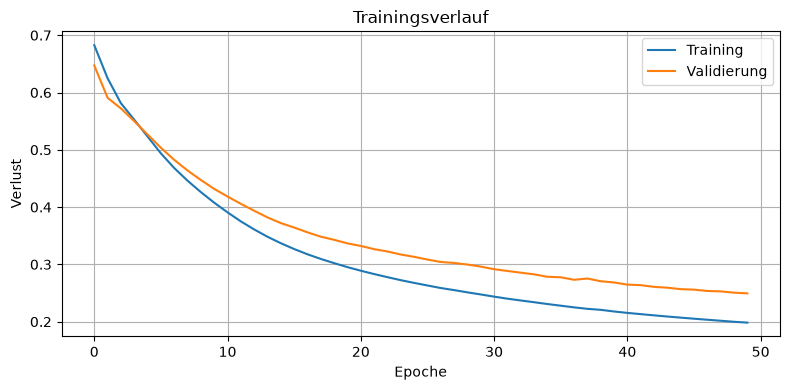

In [62]:
#|include: false

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Daten vorbereiten: normieren und zu Vektoren umformen
x = x_data.astype('float32') / 255.
x = x.reshape(-1, 784)

# Trainings-/Test-Split
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y_data[:split], y_data[split:]

# Modell definieren
input_size   = 784
encoding_size = 64

input_layer    = Input(shape=(input_size,))
encoding_layer = Dense(encoding_size, activation='relu')(input_layer)
decoding_layer = Dense(input_size,    activation='sigmoid')(encoding_layer)

autoencoder = Model(input_layer, decoding_layer)
encoder     = Model(input_layer, encoding_layer)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

# Training
history = autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Trainingsverlauf
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training')
plt.plot(history.history['val_loss'], label='Validierung')
plt.xlabel('Epoche')
plt.ylabel('Verlust')
plt.title('Trainingsverlauf')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


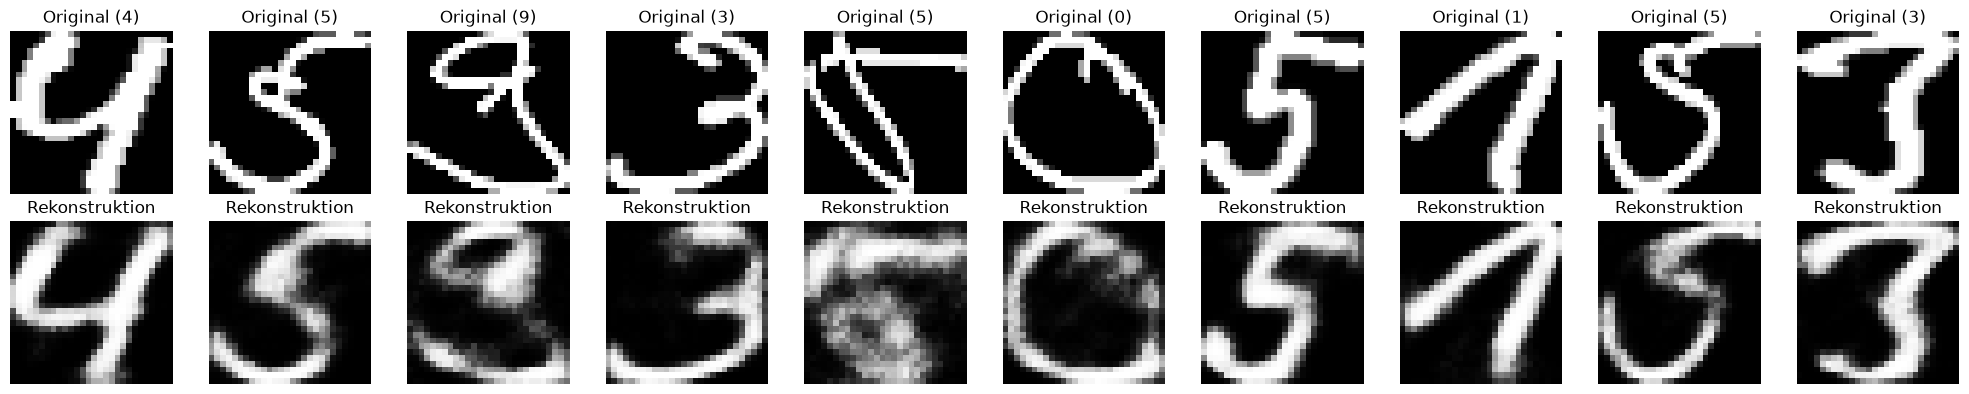

In [63]:
#|include: false

# Rekonstruktionen visualisieren
# digit: gewünschte Ziffer (0-9), oder None für zufällige Auswahl
digit = None

n = 10
if digit is None:
    idx = np.random.choice(len(x_test), size=n, replace=False)
else:
    idx = np.where(y_test == digit)[0]
    idx = np.random.choice(idx, size=n, replace=False)

x_sample         = x_test[idx]
rekonstruktionen = autoencoder.predict(x_sample)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_sample[i].reshape(28, 28), cmap='gray')
    plt.title(f'Original ({y_test[idx[i]]})')
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(rekonstruktionen[i].reshape(28, 28), cmap='gray')
    plt.title('Rekonstruktion')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Aufgabe 5

Verwenden Sie folgenden [Testdatensatz](Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Gemischt.png). Können Sie die Zeichen identifizieren, die keine Ziffern sind?

Gefundene Zeichen: 64


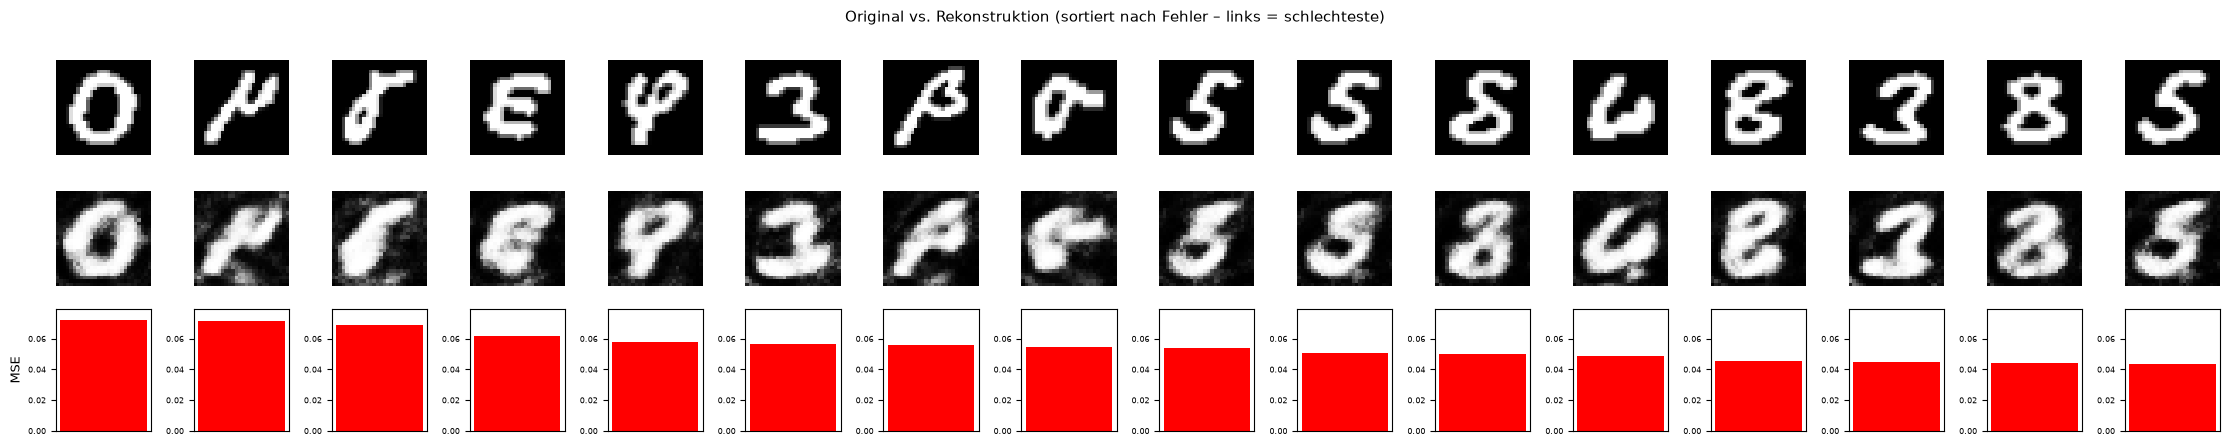

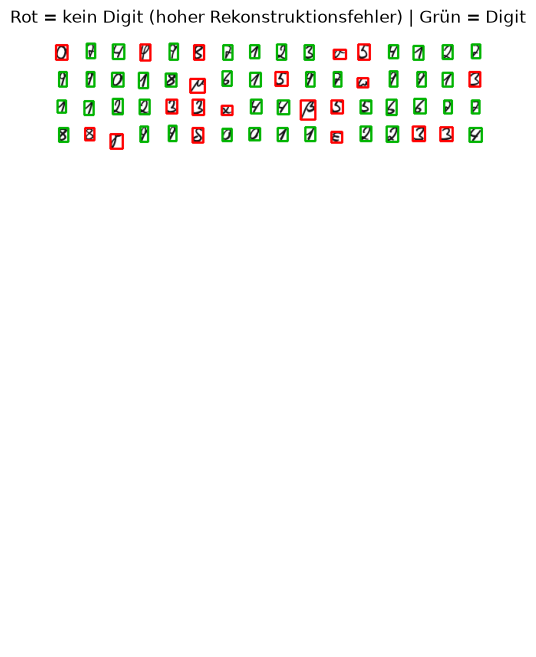

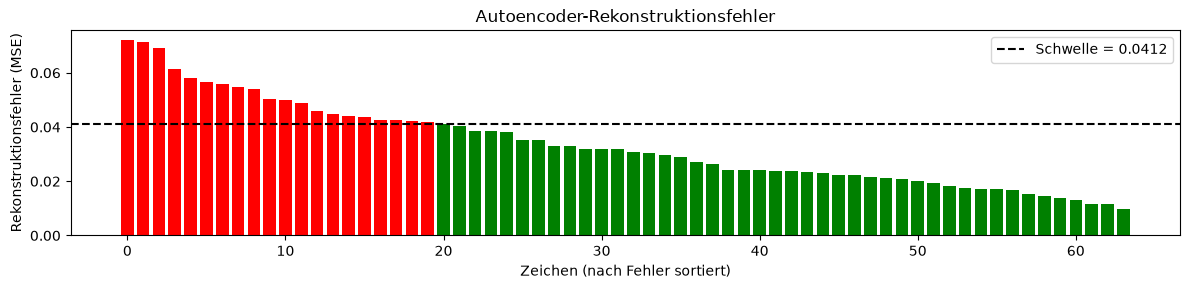

In [64]:
#|include: false

image_gemischt = cv2.imread('Daten/NichtUeberwachtesLernen/Zahlen/Zahlen_Gemischt.png')

gray   = cv2.cvtColor(image_gemischt, cv2.COLOR_BGR2GRAY)
blur   = cv2.GaussianBlur(gray, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blur, 255, 1, 1, 11, 2)

contours_g, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_g    = sort_contours_grid(contours_g, row_height=30)

x_list     = []
positionen = []

for cnt in contours_g:
    if cv2.contourArea(cnt) > 50:
        xc, yc, wc, hc = cv2.boundingRect(cnt)
        roi    = thresh[yc:yc + hc, xc:xc + wc]
        pad    = 3
        padded = cv2.copyMakeBorder(roi, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)
        x_list.append(cv2.resize(padded, (28, 28)))
        positionen.append((xc, yc, wc, hc))

print(f'Gefundene Zeichen: {len(x_list)}')

# Bilder aus einer Liste in ein NumPy-Array umwandeln, Pixelwerte von [0, 255] auf [0.0, 1.0] normieren 
x_g      = np.array(x_list).astype('float32') / 255.
x_g_flat = x_g.reshape(-1, 784)
# Der Autoencoder rekonstruiert jedes Bild.
rekon    = autoencoder.predict(x_g_flat, verbose=0)
# Fehler zwischen Originalbild und Rekonstruktion bestimmen
fehler   = np.mean((x_g_flat - rekon) ** 2, axis=1)

schwelle = np.mean(fehler) + 0.5 * np.std(fehler)

# Original vs. Rekonstruktion (nach Rekonstruktionsfehler sortiert)
n_show    = min(16, len(x_list))
idx_show  = np.argsort(fehler)[::-1][:n_show]   # die n mit höchstem Fehler zuerst

fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.4, 4.5))
for col, i in enumerate(idx_show):
    # Original
    axes[0, col].imshow(x_g_flat[i].reshape(28, 28), cmap='gray')
    axes[0, col].axis('off')
    # Rekonstruktion
    axes[1, col].imshow(rekon[i].reshape(28, 28), cmap='gray')
    axes[1, col].axis('off')
    # Fehlerbalken
    farbe = 'red' if fehler[i] > schwelle else 'green'
    axes[2, col].bar([0], [fehler[i]], color=farbe)
    axes[2, col].set_ylim(0, fehler.max() * 1.1)
    axes[2, col].set_xticks([])
    axes[2, col].tick_params(labelsize=6)

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Rekonstruktion', fontsize=9)
axes[2, 0].set_ylabel('MSE', fontsize=9)
fig.suptitle('Original vs. Rekonstruktion (sortiert nach Fehler – links = schlechteste)', fontsize=11)
plt.tight_layout()
plt.show()

# Bild mit Bounding Boxes
bild_markiert = image_gemischt.copy()
for i, (xc, yc, wc, hc) in enumerate(positionen):
    farbe = (0, 0, 255) if fehler[i] > schwelle else (0, 180, 0)
    cv2.rectangle(bild_markiert, (xc, yc), (xc + wc, yc + hc), farbe, 2)

imshow('Rot = kein Digit (hoher Rekonstruktionsfehler) | Grün = Digit', bild_markiert)
plt.show()

plt.figure(figsize=(12, 3))
idx_sorted = np.argsort(fehler)[::-1]
farben     = ['red' if fehler[i] > schwelle else 'green' for i in idx_sorted]
plt.bar(range(len(fehler)), fehler[idx_sorted], color=farben)
plt.axhline(schwelle, color='black', linestyle='--', label=f'Schwelle = {schwelle:.4f}')
plt.xlabel('Zeichen (nach Fehler sortiert)')
plt.ylabel('Rekonstruktionsfehler (MSE)')
plt.title('Autoencoder-Rekonstruktionsfehler')
plt.legend()
plt.tight_layout()
plt.show()
